# Random Walk Analysis and Visualization

This notebook analyzes the random walk results from the multi-view recommendation system.

**Analysis Components:**
1. Random Walk Parameters
2. Embedding Statistics (Tag & Text Views)
3. Embedding Distribution Visualization
4. Similarity Matrix Analysis
5. View Comparison

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

# Paths
BASE_DIR = Path('tmp')
OUTPUT_DIR = Path('random_walk_analysis_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete!")

Setup complete!


## 1. Random Walk Parameters

In [2]:
# Load random walk parameters
params_path = BASE_DIR / 'rw_params.parquet'

if params_path.exists():
    params_df = pd.read_parquet(params_path)
    
    print("=" * 70)
    print("RANDOM WALK CONFIGURATION")
    print("=" * 70)
    
    for col in params_df.columns:
        value = params_df[col].iloc[0]
        print(f"{col:35s}: {value}")
    
    print("=" * 70)
    
    # Display as DataFrame
    display(params_df.T)
else:
    print(f"Parameters file not found: {params_path}")

RANDOM WALK CONFIGURATION
RW_WALKS_PER_DOC                   : 10
RW_L_DOCS_PER_SENT                 : 40
RW_SEED_BASE                       : 2025
RW_AVOID_BACKTRACK                 : True
RW_RESTART_PROB                    : 0.15
RW_X_DEGREE_POW                    : -0.5
RW_X_NO_REPEAT_LAST                : 1


,0
RW_WALKS_PER_DOC,10
RW_L_DOCS_PER_SENT,40
RW_SEED_BASE,2025
RW_AVOID_BACKTRACK,True
RW_RESTART_PROB,0.15
RW_X_DEGREE_POW,-0.5
RW_X_NO_REPEAT_LAST,1


## 2. Load Embeddings

In [3]:
def load_embeddings(view='tag', epoch='final'):
    """Load embedding for a specific view and epoch"""
    if epoch == 'final':
        path = BASE_DIR / f'Z_{view}.parquet'
    else:
        path = BASE_DIR / f'Z_{view}_epoch{epoch}.parquet'
    
    if path.exists():
        return pd.read_parquet(path)
    return None

def load_all_epochs(view='tag'):
    """Load all available epochs for a view"""
    embeddings = {}
    
    # Load final
    final = load_embeddings(view, 'final')
    if final is not None:
        embeddings['final'] = final
    
    # Load epochs 1-4
    for epoch in range(1, 5):
        emb = load_embeddings(view, epoch)
        if emb is not None:
            embeddings[f'epoch{epoch}'] = emb
    
    return embeddings

# Load all embeddings
print("Loading embeddings...")
tag_embeddings = load_all_epochs('tag')
text_embeddings = load_all_epochs('text')

print(f"\nTag View Embeddings: {list(tag_embeddings.keys())}")
print(f"Text View Embeddings: {list(text_embeddings.keys())}")

if 'final' in tag_embeddings:
    print(f"\nTag Embedding Shape: {tag_embeddings['final'].shape}")
if 'final' in text_embeddings:
    print(f"Text Embedding Shape: {text_embeddings['final'].shape}")

Loading embeddings...

Tag View Embeddings: ['final', 'epoch1', 'epoch2', 'epoch3', 'epoch4']
Text View Embeddings: ['final', 'epoch1', 'epoch2']

Tag Embedding Shape: (521735, 257)
Text Embedding Shape: (521735, 257)


## 3. Embedding Statistics

In [4]:
def compute_embedding_stats(embeddings_dict, view_name):
    """Compute statistics for embeddings"""
    stats = []
    
    for name, emb_df in embeddings_dict.items():
        emb_array = emb_df.values if isinstance(emb_df, pd.DataFrame) else emb_df
        
        stat = {
            'View': view_name,
            'Version': name,
            'Docs': emb_array.shape[0],
            'Dims': emb_array.shape[1],
            'Mean': np.mean(emb_array),
            'Std': np.std(emb_array),
            'Min': np.min(emb_array),
            'Max': np.max(emb_array),
            'L2_Norm_Mean': np.mean(np.linalg.norm(emb_array, axis=1)),
            'L2_Norm_Std': np.std(np.linalg.norm(emb_array, axis=1))
        }
        stats.append(stat)
    
    return pd.DataFrame(stats)

# Compute statistics
tag_stats = compute_embedding_stats(tag_embeddings, 'Tag')
text_stats = compute_embedding_stats(text_embeddings, 'Text')

all_stats = pd.concat([tag_stats, text_stats], ignore_index=True)

print("\nEMBEDDING STATISTICS\n")
display(all_stats.style.format({
    'Mean': '{:.4f}',
    'Std': '{:.4f}',
    'Min': '{:.4f}',
    'Max': '{:.4f}',
    'L2_Norm_Mean': '{:.4f}',
    'L2_Norm_Std': '{:.4f}'
}))


EMBEDDING STATISTICS



,View,Version,Docs,Dims,Mean,Std,Min,Max,L2_Norm_Mean,L2_Norm_Std
0,Tag,final,521735,257,1015.0467,18762.3630,-0.1243,521734.0000,260867.0000,150611.9213
1,Tag,epoch1,521735,257,1015.0467,18762.3630,-0.1243,521734.0000,260867.0000,150611.9213
2,Tag,epoch2,521735,257,1015.0467,18762.3630,-0.1243,521734.0000,260867.0000,150611.9213
3,Tag,epoch3,521735,257,1015.0467,18762.3630,-0.1243,521734.0000,260867.0000,150611.9213
4,Tag,epoch4,521735,257,1015.0467,18762.3630,-0.1243,521734.0000,260867.0000,150611.9213
5,Text,final,521735,257,1015.0467,18762.3630,-0.1237,521734.0000,260867.0000,150611.9213
6,Text,epoch1,521735,257,1015.0467,18762.3630,-0.1237,521734.0000,260867.0000,150611.9213
7,Text,epoch2,521735,257,1015.0467,18762.3630,-0.1237,521734.0000,260867.0000,150611.9213


## 4. Visualize Embedding Distributions

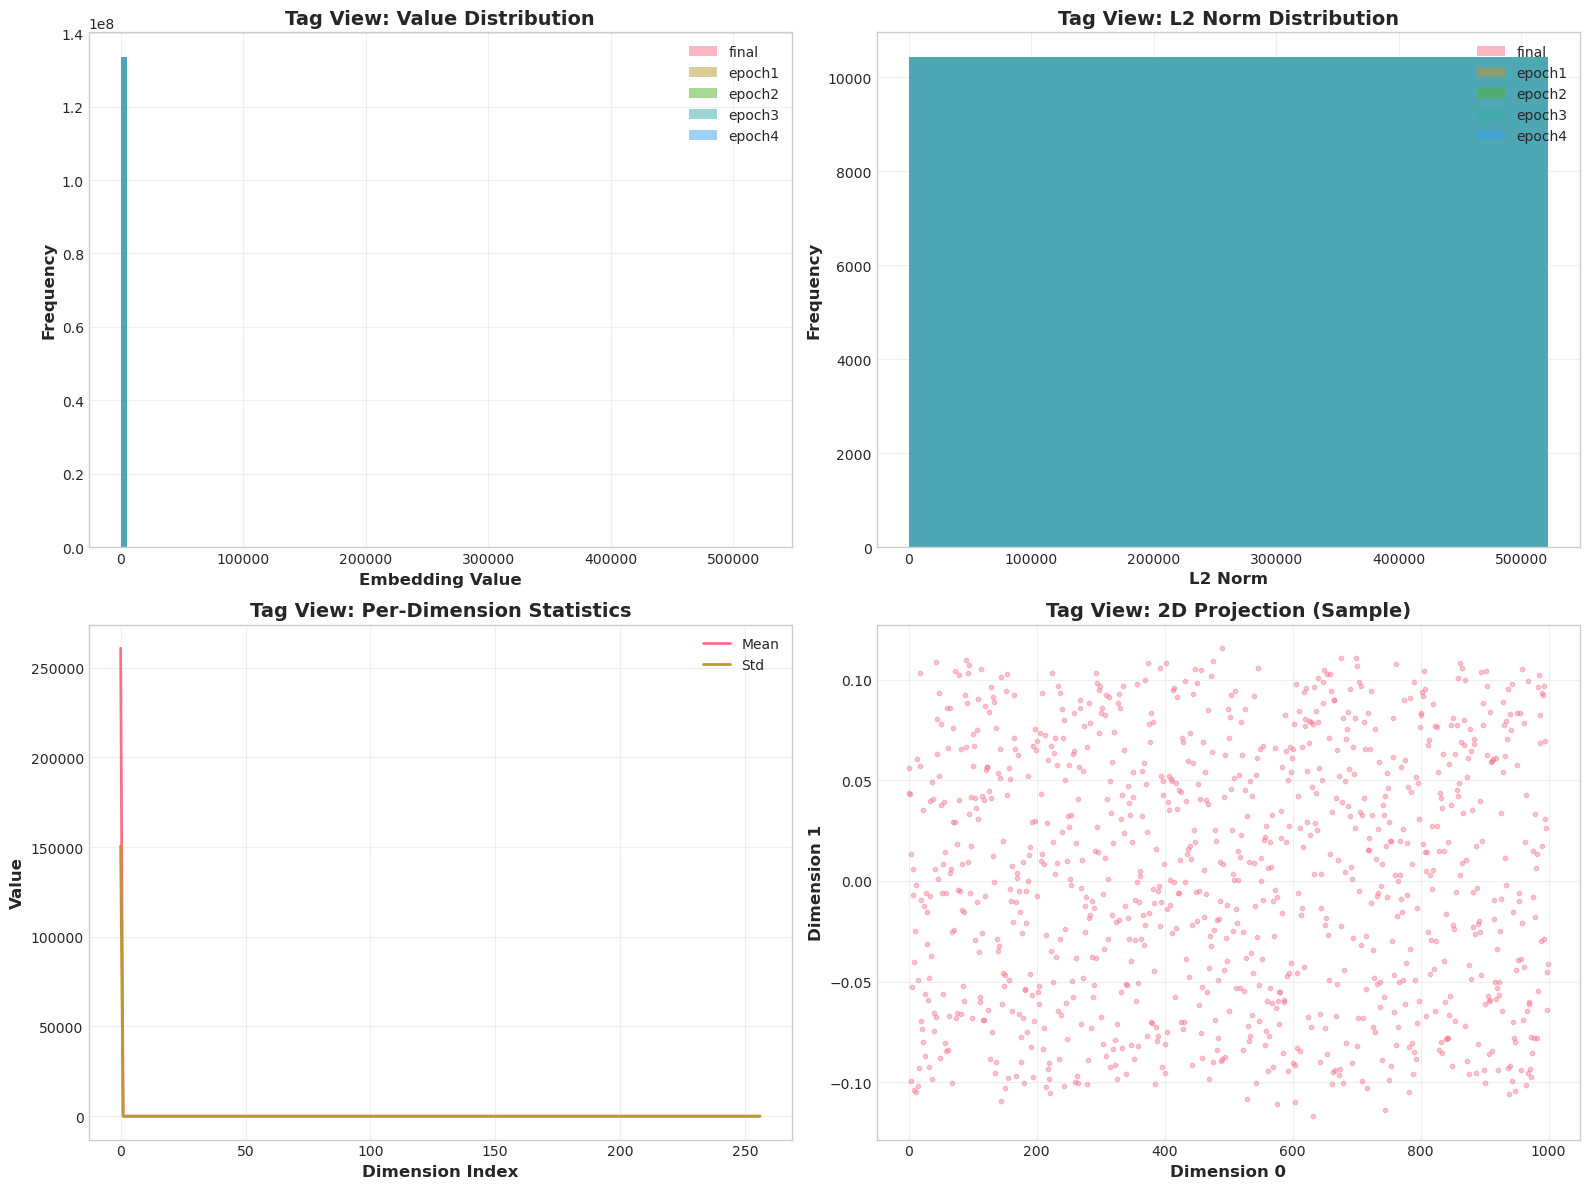

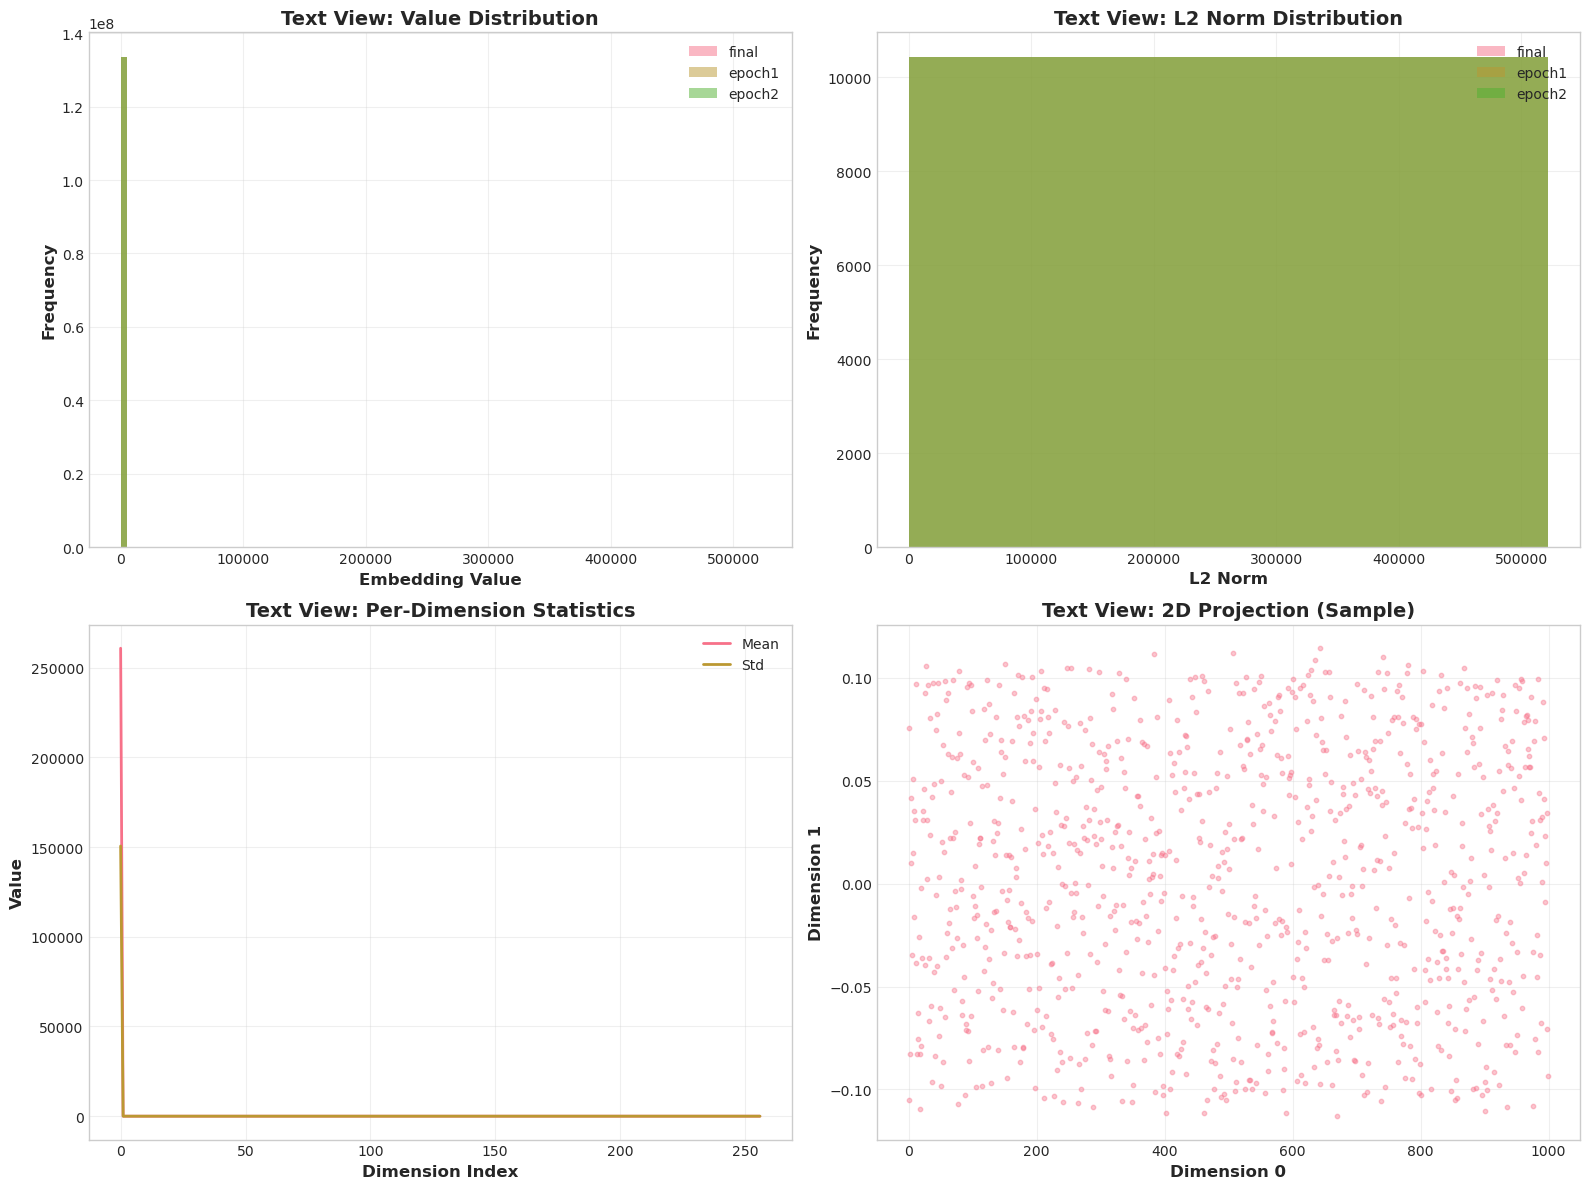

In [5]:
def plot_embedding_distribution(embeddings_dict, view_name):
    """Plot embedding distributions"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Value Distribution
    for name, emb_df in embeddings_dict.items():
        emb_array = emb_df.values if isinstance(emb_df, pd.DataFrame) else emb_df
        axes[0, 0].hist(emb_array.flatten(), bins=100, alpha=0.5, label=name)
    
    axes[0, 0].set_xlabel('Embedding Value', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_title(f'{view_name} View: Value Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: L2 Norm Distribution
    for name, emb_df in embeddings_dict.items():
        emb_array = emb_df.values if isinstance(emb_df, pd.DataFrame) else emb_df
        norms = np.linalg.norm(emb_array, axis=1)
        axes[0, 1].hist(norms, bins=50, alpha=0.5, label=name)
    
    axes[0, 1].set_xlabel('L2 Norm', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 1].set_title(f'{view_name} View: L2 Norm Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: Dimension Statistics (using final)
    if 'final' in embeddings_dict:
        emb_df = embeddings_dict['final']
        emb_array = emb_df.values if isinstance(emb_df, pd.DataFrame) else emb_df
        
        dim_means = np.mean(emb_array, axis=0)
        dim_stds = np.std(emb_array, axis=0)
        
        axes[1, 0].plot(dim_means, label='Mean', linewidth=2)
        axes[1, 0].plot(dim_stds, label='Std', linewidth=2)
        axes[1, 0].set_xlabel('Dimension Index', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Value', fontsize=12, fontweight='bold')
        axes[1, 0].set_title(f'{view_name} View: Per-Dimension Statistics', fontsize=14, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: 2D Projection Sample
    if 'final' in embeddings_dict:
        emb_df = embeddings_dict['final']
        emb_array = emb_df.values if isinstance(emb_df, pd.DataFrame) else emb_df
        
        sample = emb_array[:1000, :2]  # First 1000 docs, first 2 dims
        axes[1, 1].scatter(sample[:, 0], sample[:, 1], alpha=0.4, s=10)
        axes[1, 1].set_xlabel('Dimension 0', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Dimension 1', fontsize=12, fontweight='bold')
        axes[1, 1].set_title(f'{view_name} View: 2D Projection (Sample)', fontsize=14, fontweight='bold')
        axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot Tag View
if tag_embeddings:
    fig_tag = plot_embedding_distribution(tag_embeddings, 'Tag')
    plt.savefig(OUTPUT_DIR / 'tag_embedding_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot Text View
if text_embeddings:
    fig_text = plot_embedding_distribution(text_embeddings, 'Text')
    plt.savefig(OUTPUT_DIR / 'text_embedding_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Compare Tag and Text Views

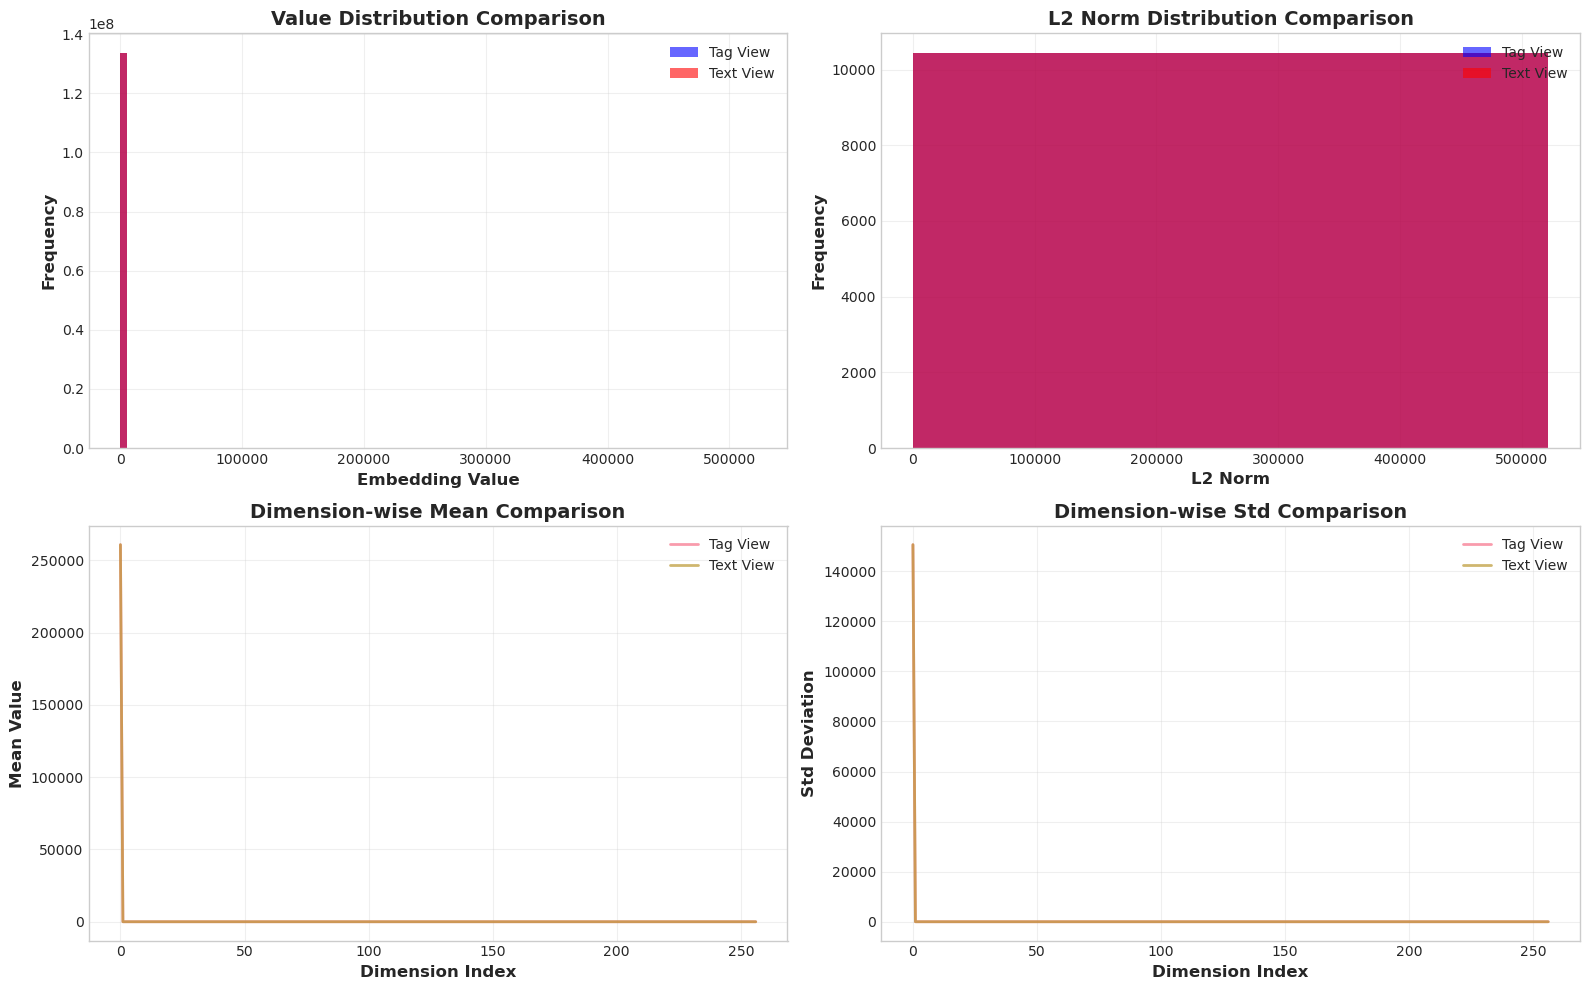


NUMERICAL COMPARISON

Tag View:
  Mean: 1015.046692, Std: 18762.363017
  L2 Norm - Mean: 260867.000015, Std: 150611.921325

Text View:
  Mean: 1015.046698, Std: 18762.363017
  L2 Norm - Mean: 260867.000015, Std: 150611.921325


In [6]:
if 'final' in tag_embeddings and 'final' in text_embeddings:
    tag_array = tag_embeddings['final'].values
    text_array = text_embeddings['final'].values
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Value Distribution Comparison
    axes[0, 0].hist(tag_array.flatten(), bins=100, alpha=0.6, label='Tag View', color='blue')
    axes[0, 0].hist(text_array.flatten(), bins=100, alpha=0.6, label='Text View', color='red')
    axes[0, 0].set_xlabel('Embedding Value', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Value Distribution Comparison', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: L2 Norm Comparison
    tag_norms = np.linalg.norm(tag_array, axis=1)
    text_norms = np.linalg.norm(text_array, axis=1)
    
    axes[0, 1].hist(tag_norms, bins=50, alpha=0.6, label='Tag View', color='blue')
    axes[0, 1].hist(text_norms, bins=50, alpha=0.6, label='Text View', color='red')
    axes[0, 1].set_xlabel('L2 Norm', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('L2 Norm Distribution Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: Dimension-wise Mean
    tag_dim_means = np.mean(tag_array, axis=0)
    text_dim_means = np.mean(text_array, axis=0)
    
    axes[1, 0].plot(tag_dim_means, label='Tag View', linewidth=2, alpha=0.7)
    axes[1, 0].plot(text_dim_means, label='Text View', linewidth=2, alpha=0.7)
    axes[1, 0].set_xlabel('Dimension Index', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Mean Value', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Dimension-wise Mean Comparison', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Dimension-wise Std
    tag_dim_stds = np.std(tag_array, axis=0)
    text_dim_stds = np.std(text_array, axis=0)
    
    axes[1, 1].plot(tag_dim_stds, label='Tag View', linewidth=2, alpha=0.7)
    axes[1, 1].plot(text_dim_stds, label='Text View', linewidth=2, alpha=0.7)
    axes[1, 1].set_xlabel('Dimension Index', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Std Deviation', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Dimension-wise Std Comparison', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'view_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print numerical comparison
    print("\n" + "="*70)
    print("NUMERICAL COMPARISON")
    print("="*70)
    print(f"\nTag View:")
    print(f"  Mean: {np.mean(tag_array):.6f}, Std: {np.std(tag_array):.6f}")
    print(f"  L2 Norm - Mean: {np.mean(tag_norms):.6f}, Std: {np.std(tag_norms):.6f}")
    print(f"\nText View:")
    print(f"  Mean: {np.mean(text_array):.6f}, Std: {np.std(text_array):.6f}")
    print(f"  L2 Norm - Mean: {np.mean(text_norms):.6f}, Std: {np.std(text_norms):.6f}")
else:
    print("Both tag and text final embeddings needed for comparison")

## 6. Load and Analyze Similarity Matrices

In [7]:
def load_similarity_matrix(matrix_name):
    """Load similarity matrix from manifest and parts"""
    manifest_path = BASE_DIR / f'{matrix_name}_manifest.json'
    
    if not manifest_path.exists():
        print(f"Manifest not found: {manifest_path}")
        return None, None
    
    with open(manifest_path, 'r') as f:
        manifest = json.load(f)
    
    print(f"Loading {matrix_name}...")
    print(f"  Shape: {manifest['shape']}")
    print(f"  Non-zeros: {manifest['nnz']:,}")
    print(f"  Sparsity: {(1 - manifest['nnz'] / (manifest['shape'][0] * manifest['shape'][1])) * 100:.4f}%")
    
    # Load parts
    all_rows, all_cols, all_data = [], [], []
    
    for part_info in manifest['parts']:
        part_path = BASE_DIR / part_info['path']
        if part_path.exists():
            df = pd.read_parquet(part_path)
            all_rows.extend(df['row'].values)
            all_cols.extend(df['col'].values)
            all_data.extend(df['val'].values)
    
    shape = tuple(manifest['shape'])
    sparse_matrix = csr_matrix((all_data, (all_rows, all_cols)), shape=shape)
    
    return sparse_matrix, manifest

# Load similarity matrices
print("\n" + "="*70)
print("LOADING SIMILARITY MATRICES")
print("="*70 + "\n")

tag_sim, tag_manifest = load_similarity_matrix('S_tag_symrow_k50')
print()
text_sim, text_manifest = load_similarity_matrix('S_text_symrow_k50')


LOADING SIMILARITY MATRICES

Loading S_tag_symrow_k50...


KeyError: 'shape'

## 7. Similarity Matrix Statistics

In [ ]:
def analyze_sparse_matrix(sparse_matrix, name):
    """Analyze sparse matrix statistics"""
    print(f"\n{'='*70}")
    print(f"ANALYSIS: {name}")
    print("="*70)
    
    # Degree statistics
    degrees = np.array(sparse_matrix.sum(axis=1)).flatten()
    nonzero_degrees = degrees[degrees > 0]
    
    print(f"\nDegree Statistics:")
    print(f"  Min: {np.min(nonzero_degrees):.4f}")
    print(f"  Max: {np.max(nonzero_degrees):.4f}")
    print(f"  Mean: {np.mean(nonzero_degrees):.4f}")
    print(f"  Median: {np.median(nonzero_degrees):.4f}")
    print(f"  Std: {np.std(nonzero_degrees):.4f}")
    
    # Value statistics
    values = sparse_matrix.data
    print(f"\nValue Statistics:")
    print(f"  Min: {np.min(values):.6f}")
    print(f"  Max: {np.max(values):.6f}")
    print(f"  Mean: {np.mean(values):.6f}")
    print(f"  Median: {np.median(values):.6f}")
    print(f"  Std: {np.std(values):.6f}")
    
    # Edges per row
    edges_per_row = np.diff(sparse_matrix.indptr)
    nonzero_edges = edges_per_row[edges_per_row > 0]
    
    print(f"\nEdges Per Row:")
    print(f"  Min: {np.min(nonzero_edges)}")
    print(f"  Max: {np.max(nonzero_edges)}")
    print(f"  Mean: {np.mean(nonzero_edges):.2f}")
    print(f"  Median: {np.median(nonzero_edges):.0f}")
    
    return {
        'degrees': degrees,
        'values': values,
        'edges_per_row': edges_per_row
    }

# Analyze matrices
if tag_sim is not None:
    tag_stats = analyze_sparse_matrix(tag_sim, 'Tag Similarity Matrix')

if text_sim is not None:
    text_stats = analyze_sparse_matrix(text_sim, 'Text Similarity Matrix')

## 8. Visualize Similarity Matrix Statistics

In [ ]:
def plot_matrix_stats(stats, name):
    """Plot similarity matrix statistics"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Degree distribution
    degrees = stats['degrees']
    nonzero_degrees = degrees[degrees > 0]
    axes[0, 0].hist(nonzero_degrees, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Degree (Row Sum)', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_title(f'{name}: Degree Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: Value distribution
    values = stats['values']
    axes[0, 1].hist(values, bins=100, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Similarity Value', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 1].set_title(f'{name}: Value Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: Edges per row
    edges_per_row = stats['edges_per_row']
    nonzero_edges = edges_per_row[edges_per_row > 0]
    axes[1, 0].hist(nonzero_edges, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Edges Per Row', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[1, 0].set_title(f'{name}: Edges Per Row Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Log-log degree distribution
    degree_counts = np.bincount(nonzero_edges.astype(int))
    nonzero_counts = np.where(degree_counts > 0)[0]
    axes[1, 1].loglog(nonzero_counts, degree_counts[nonzero_counts], 'o-', alpha=0.7)
    axes[1, 1].set_xlabel('Edges Per Row (log)', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Frequency (log)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title(f'{name}: Power Law Check', fontsize=14, fontweight='bold')
    axes[1, 1].grid(alpha=0.3, which='both')
    
    plt.tight_layout()
    return fig

# Plot tag similarity matrix
if tag_sim is not None and tag_stats is not None:
    fig = plot_matrix_stats(tag_stats, 'Tag Similarity Matrix')
    plt.savefig(OUTPUT_DIR / 'tag_similarity_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot text similarity matrix
if text_sim is not None and text_stats is not None:
    fig = plot_matrix_stats(text_stats, 'Text Similarity Matrix')
    plt.savefig(OUTPUT_DIR / 'text_similarity_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Summary Report

In [ ]:
print("\n" + "="*70)
print("RANDOM WALK ANALYSIS - SUMMARY REPORT")
print("="*70)

print("\n1. EMBEDDINGS:")
print(f"   Tag View: {len(tag_embeddings)} versions available")
print(f"   Text View: {len(text_embeddings)} versions available")

if 'final' in tag_embeddings:
    tag_array = tag_embeddings['final'].values
    print(f"\n   Tag Final Embedding:")
    print(f"     Shape: {tag_array.shape}")
    print(f"     Mean L2 Norm: {np.mean(np.linalg.norm(tag_array, axis=1)):.4f}")

if 'final' in text_embeddings:
    text_array = text_embeddings['final'].values
    print(f"\n   Text Final Embedding:")
    print(f"     Shape: {text_array.shape}")
    print(f"     Mean L2 Norm: {np.mean(np.linalg.norm(text_array, axis=1)):.4f}")

print("\n2. SIMILARITY MATRICES:")
if tag_manifest:
    print(f"   Tag Matrix: {tag_manifest['shape']}, {tag_manifest['nnz']:,} edges")
if text_manifest:
    print(f"   Text Matrix: {text_manifest['shape']}, {text_manifest['nnz']:,} edges")

print("\n3. OUTPUT FILES:")
output_files = list(OUTPUT_DIR.glob('*.png'))
for f in output_files:
    print(f"   - {f.name}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print(f"All visualizations saved to: {OUTPUT_DIR}/")
print("="*70)